### IMPORTING NECESSARY MODULES TO LOAD DATASET

In [3]:
import pandas as pd
import numpy as np

### Data read from csv file

In [4]:
df=pd.read_csv("train_aWnotuB.csv")

In [5]:
df

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041
...,...,...,...,...
48115,2017-06-30 19:00:00,4,11,20170630194
48116,2017-06-30 20:00:00,4,30,20170630204
48117,2017-06-30 21:00:00,4,16,20170630214
48118,2017-06-30 22:00:00,4,22,20170630224


# EDA

In [6]:
df.describe()

,Junction,Vehicles,ID
count,48120.000000,48120.000000,4.812000e+04
mean,2.180549,22.791334,2.016330e+10
std,0.966955,20.750063,5.944854e+06
min,1.000000,1.000000,2.015110e+10
25%,1.000000,9.000000,2.016042e+10
50%,2.000000,15.000000,2.016093e+10
75%,3.000000,29.000000,2.017023e+10
max,4.000000,180.000000,2.017063e+10


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [8]:
df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [9]:
df.tail()

,DateTime,Junction,Vehicles,ID
48115,2017-06-30 19:00:00,4,11,20170630194
48116,2017-06-30 20:00:00,4,30,20170630204
48117,2017-06-30 21:00:00,4,16,20170630214
48118,2017-06-30 22:00:00,4,22,20170630224
48119,2017-06-30 23:00:00,4,12,20170630234


In [10]:
df.isnull().sum()

DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

### creating datetime object

In [14]:
df['DateTime']=pd.to_datetime(df['DateTime'])

In [15]:
df['Hour'] = df['DateTime'].dt.hour              
df['Date'] = df['DateTime'].dt.date 
df['Year']=df['DateTime'].dt.year
df['weekday']=df['DateTime'].dt.weekday+1

In [16]:
df

,DateTime,Junction,Vehicles,ID,Hour,Date,Year,weekday
0,2015-11-01 00:00:00,1,15,20151101001,0,2015-11-01,2015,7
1,2015-11-01 01:00:00,1,13,20151101011,1,2015-11-01,2015,7
2,2015-11-01 02:00:00,1,10,20151101021,2,2015-11-01,2015,7
3,2015-11-01 03:00:00,1,7,20151101031,3,2015-11-01,2015,7
4,2015-11-01 04:00:00,1,9,20151101041,4,2015-11-01,2015,7
...,...,...,...,...,...,...,...,...
48115,2017-06-30 19:00:00,4,11,20170630194,19,2017-06-30,2017,5
48116,2017-06-30 20:00:00,4,30,20170630204,20,2017-06-30,2017,5
48117,2017-06-30 21:00:00,4,16,20170630214,21,2017-06-30,2017,5
48118,2017-06-30 22:00:00,4,22,20170630224,22,2017-06-30,2017,5


In [17]:
df=df.drop('DateTime',axis=1)

In [18]:
df

,Junction,Vehicles,ID,Hour,Date,Year,weekday
0,1,15,20151101001,0,2015-11-01,2015,7
1,1,13,20151101011,1,2015-11-01,2015,7
2,1,10,20151101021,2,2015-11-01,2015,7
3,1,7,20151101031,3,2015-11-01,2015,7
4,1,9,20151101041,4,2015-11-01,2015,7
...,...,...,...,...,...,...,...
48115,4,11,20170630194,19,2017-06-30,2017,5
48116,4,30,20170630204,20,2017-06-30,2017,5
48117,4,16,20170630214,21,2017-06-30,2017,5
48118,4,22,20170630224,22,2017-06-30,2017,5


In [19]:
df.drop('ID',axis=1)

,Junction,Vehicles,Hour,Date,Year,weekday
0,1,15,0,2015-11-01,2015,7
1,1,13,1,2015-11-01,2015,7
2,1,10,2,2015-11-01,2015,7
3,1,7,3,2015-11-01,2015,7
4,1,9,4,2015-11-01,2015,7
...,...,...,...,...,...,...
48115,4,11,19,2017-06-30,2017,5
48116,4,30,20,2017-06-30,2017,5
48117,4,16,21,2017-06-30,2017,5
48118,4,22,22,2017-06-30,2017,5


In [20]:
df.isnull().sum()

Junction    0
Vehicles    0
ID          0
Hour        0
Date        0
Year        0
weekday     0
dtype: int64

In [21]:
df.duplicated().sum()


0

In [22]:
import holidays
df['Date'] = pd.to_datetime(df['Date']) 

indian_holidays = holidays.India(years=df['Date'].dt.year.unique())

# Custom function to check if the date is a holiday in India
def is_holiday_in_india(date):
    return date in indian_holidays
    
# Apply the custom function to the 'Date' column
df['IsHoliday'] = df['Date'].apply(lambda x: is_holiday_in_india(x))


In [23]:
df['IsHoliday']

0        False
1        False
2        False
3        False
4        False
         ...  
48115    False
48116    False
48117    False
48118    False
48119    False
Name: IsHoliday, Length: 48120, dtype: bool

In [24]:
map={True:1,False:0}
df['IsHoliday'].map(map)

0        0
1        0
2        0
3        0
4        0
        ..
48115    0
48116    0
48117    0
48118    0
48119    0
Name: IsHoliday, Length: 48120, dtype: int64

In [25]:
df['IsHoliday'].value_counts()

IsHoliday
False    45648
True      2472
Name: count, dtype: int64

In [26]:
df.isnull().sum()

Junction     0
Vehicles     0
ID           0
Hour         0
Date         0
Year         0
weekday      0
IsHoliday    0
dtype: int64

# 

In [27]:
import matplotlib.pyplot as plt

In [28]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.templates.default = "plotly_white"

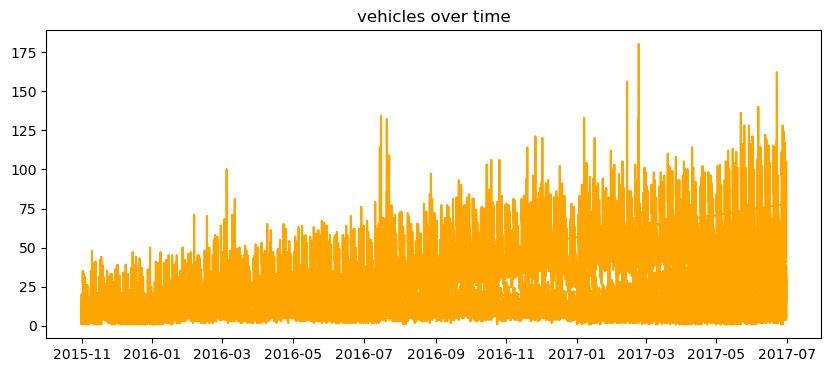

In [34]:
plt.figure(figsize=(10,4))
plt.plot(df['Date'],df['Vehicles'],color='orange')
plt.title("vehicles over time")
plt.show()

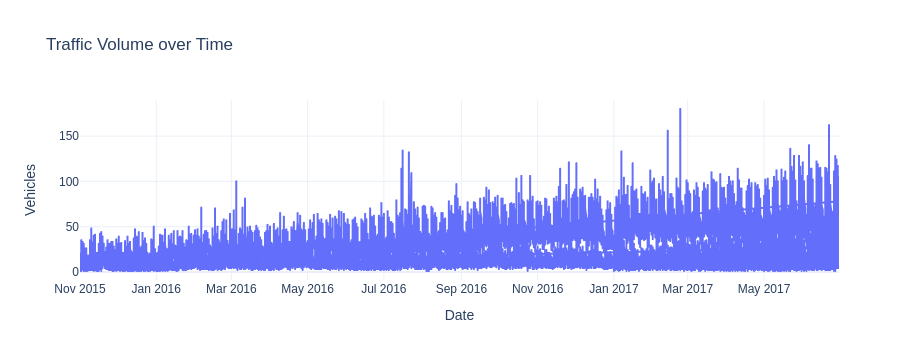

In [169]:
fig = px.line(df, x='Date', y='Vehicles', title='Traffic Volume over Time')
fig.show()

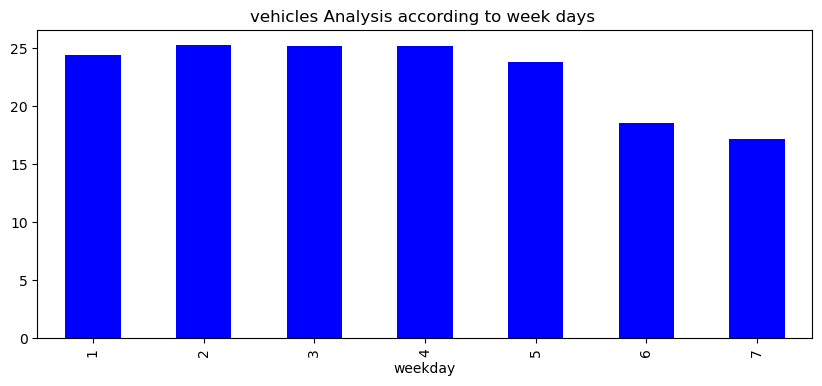

In [46]:
plt.figure(figsize=(10,4))
#plt.plot(df['weekday'],df['Vehicles'],color='orange')
df.groupby('weekday')['Vehicles'].mean().plot(kind='bar',color='b')
plt.title("vehicles Analysis according to week days ")
plt.show()

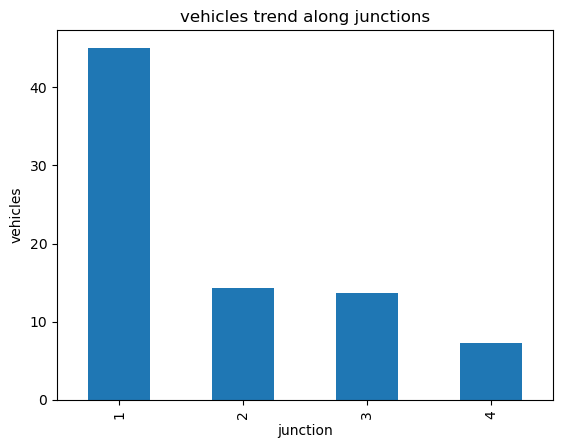

In [42]:
df.groupby('Junction')['Vehicles'].mean().plot(kind='bar')
plt.xlabel("junction")
plt.ylabel("vehicles")
plt.title("vehicles trend along junctions")
plt.show()

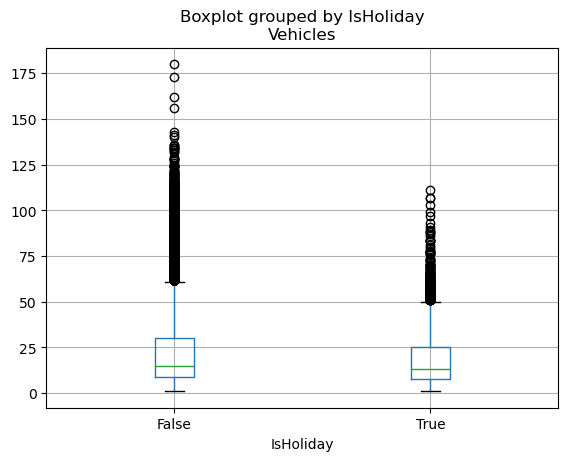

In [49]:
df.boxplot(column='Vehicles',by='IsHoliday')
#plt.xlabel("isholiday")
#plt.ylabel("vehicles")
plt.show()

### boxplot for outliers

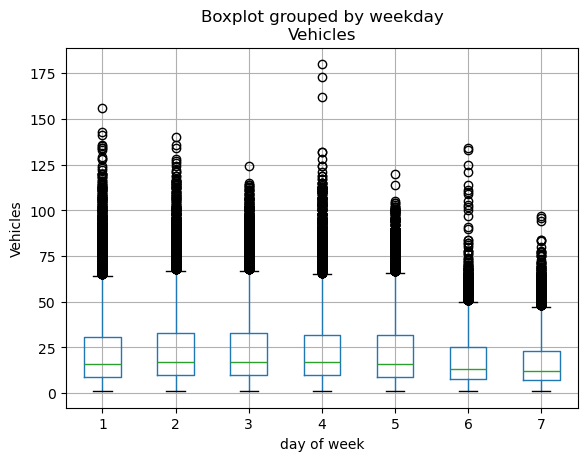

In [171]:
df.boxplot(column='Vehicles',by='weekday')
plt.xlabel("day of week")
plt.ylabel("Vehicles")
plt.show()

# Feature Engineering


In [50]:
df.isnull().sum()


Junction     0
Vehicles     0
ID           0
Hour         0
Date         0
Year         0
weekday      0
IsHoliday    0
dtype: int64

### check the corelation between them

In [51]:
df.corr()

,Junction,Vehicles,ID,Hour,Date,Year,weekday,IsHoliday
Junction,1.000000e+00,-0.613787,0.221876,-2.132575e-15,2.026885e-01,2.212977e-01,-6.590970e-04,3.279321e-03
Vehicles,-6.137872e-01,1.000000,0.227974,2.199377e-01,2.658902e-01,2.212531e-01,-1.260265e-01,-3.995644e-02
ID,2.218756e-01,0.227974,1.000000,1.164412e-05,9.000533e-01,9.988958e-01,1.131069e-03,1.268202e-02
Hour,-2.132575e-15,0.219938,0.000012,1.000000e+00,-5.709188e-16,1.431536e-16,9.124565e-18,4.789222e-18
Date,2.026885e-01,0.265890,0.900053,-5.709188e-16,1.000000e+00,8.786496e-01,-3.802312e-04,1.951299e-02
Year,2.212977e-01,0.221253,0.998896,1.431536e-16,8.786496e-01,1.000000e+00,1.278526e-03,1.176429e-02
weekday,-6.590970e-04,-0.126027,0.001131,9.124565e-18,-3.802312e-04,1.278526e-03,1.000000e+00,8.179964e-02
IsHoliday,3.279321e-03,-0.039956,0.012682,4.789222e-18,1.951299e-02,1.176429e-02,8.179964e-02,1.000000e+00


In [52]:
df=df.drop('ID',axis=1)

In [53]:
df.corr()

,Junction,Vehicles,Hour,Date,Year,weekday,IsHoliday
Junction,1.000000e+00,-0.613787,-2.132575e-15,2.026885e-01,2.212977e-01,-6.590970e-04,3.279321e-03
Vehicles,-6.137872e-01,1.000000,2.199377e-01,2.658902e-01,2.212531e-01,-1.260265e-01,-3.995644e-02
Hour,-2.132575e-15,0.219938,1.000000e+00,-5.709188e-16,1.431536e-16,9.124565e-18,4.789222e-18
Date,2.026885e-01,0.265890,-5.709188e-16,1.000000e+00,8.786496e-01,-3.802312e-04,1.951299e-02
Year,2.212977e-01,0.221253,1.431536e-16,8.786496e-01,1.000000e+00,1.278526e-03,1.176429e-02
weekday,-6.590970e-04,-0.126027,9.124565e-18,-3.802312e-04,1.278526e-03,1.000000e+00,8.179964e-02
IsHoliday,3.279321e-03,-0.039956,4.789222e-18,1.951299e-02,1.176429e-02,8.179964e-02,1.000000e+00


In [54]:
df.isnull().sum()

Junction     0
Vehicles     0
Hour         0
Date         0
Year         0
weekday      0
IsHoliday    0
dtype: int64

In [55]:
df.fillna(0,inplace=True)

In [204]:
map={True:1,False:0}
df['IsHoliday']=df['IsHoliday'].map(map)

In [205]:
df['IsHoliday'].value_counts()

IsHoliday
0    45648
1     2472
Name: count, dtype: int64

In [208]:
df['IsHoliday'].value_counts()

IsHoliday
0    45648
1     2472
Name: count, dtype: int64

In [209]:
df.tail()

,Junction,Vehicles,Hour,Date,Year,weekday,IsHoliday,pd,ph
48115,4,11,19,2017-06-30,2017,5,0,0.0,0.0
48116,4,30,20,2017-06-30,2017,5,0,0.0,0.0
48117,4,16,21,2017-06-30,2017,5,0,0.0,0.0
48118,4,22,22,2017-06-30,2017,5,0,0.0,0.0
48119,4,12,23,2017-06-30,2017,5,0,0.0,0.0


### CHECK WHEATHER DATA IS STATIONARY OR NOT¶

In [68]:
from statsmodels.tsa.stattools import adfuller

# Assume df['Vehicles'] is the time series data
result = adfuller(df['Vehicles'])

# Extract results
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:", result[4])  # 1%, 5%, and 10% confidence levels

# Decision based on p-value
if result[1] > 0.05:
    print("Series is Non-Stationary (Needs Differencing)")
else:
    print("Series is Stationary (No Differencing Needed)")


ADF Statistic: -7.518278111935717
p-value: 3.851060199915684e-11
Critical Values: {'1%': -3.430486066940443, '5%': -2.8616001387397922, '10%': -2.566802009871527}
Series is Stationary (No Differencing Needed)


### the data is stationary no need for differencing

### Save the previously done steps incase of file automatically close down we will start again here

In [211]:
df.to_csv('trainone1.csv',index=False)

In [69]:
import pandas as pd
df1=pd.read_csv("trainone1.csv")

In [275]:
df1=df1.drop(['pd','ph'],axis=1)

# Feature selection

In [71]:
from sklearn.model_selection import train_test_split
train_df,test_df=train_test_split(df1,test_size=0.2,shuffle=False)

In [72]:
print(len(train_df),len(test_df))

38496 9624


# here the target value i not at last column we modify it and make the target value at last index

In [73]:
veh=train_df['Vehicles']

In [74]:
train_df=train_df.drop('Vehicles',axis=1)

In [75]:
train_df

,Junction,Hour,Date,Year,weekday,IsHoliday,pd,ph
0,1,0,2015-11-01,2015,7,0,0.0,0.0
1,1,1,2015-11-01,2015,7,0,0.0,15.0
2,1,2,2015-11-01,2015,7,0,0.0,13.0
3,1,3,2015-11-01,2015,7,0,0.0,10.0
4,1,4,2015-11-01,2015,7,0,0.0,7.0
...,...,...,...,...,...,...,...,...
38491,3,19,2016-11-22,2016,2,0,14.0,17.0
38492,3,20,2016-11-22,2016,2,0,17.0,12.0
38493,3,21,2016-11-22,2016,2,0,16.0,17.0
38494,3,22,2016-11-22,2016,2,0,21.0,15.0


In [76]:
train_df['Vehicles']=veh

In [77]:
train_df

,Junction,Hour,Date,Year,weekday,IsHoliday,pd,ph,Vehicles
0,1,0,2015-11-01,2015,7,0,0.0,0.0,15
1,1,1,2015-11-01,2015,7,0,0.0,15.0,13
2,1,2,2015-11-01,2015,7,0,0.0,13.0,10
3,1,3,2015-11-01,2015,7,0,0.0,10.0,7
4,1,4,2015-11-01,2015,7,0,0.0,7.0,9
...,...,...,...,...,...,...,...,...,...
38491,3,19,2016-11-22,2016,2,0,14.0,17.0,12
38492,3,20,2016-11-22,2016,2,0,17.0,12.0,17
38493,3,21,2016-11-22,2016,2,0,16.0,17.0,15
38494,3,22,2016-11-22,2016,2,0,21.0,15.0,15


In [78]:
train_tar=train_df['Vehicles']
test_tar=test_df['Vehicles']

# importing necessry models and metrics

In [79]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [80]:
model=ARIMA(train_tar,order=(1,1,1))

In [81]:
model_fit=model.fit()

# Forecasting on the train dataset

In [82]:
train_predictions = model_fit.predict(start=train_df.index[0], end=train_df.index[-1])
#train_predictions = model_fit.predict(start=df1.index[0], end=df1.index[-1])

# evaluating on traing data

In [83]:
train_mse=mean_squared_error(train_df['Vehicles'],train_predictions)
train_mae=mean_absolute_error(train_df['Vehicles'],train_predictions)
train_rms=np.sqrt(train_mse)

print("training measquared error",train_mse)
print("training meanabsolute error",train_mae)
print("root meansquared error",train_rms)

training measquared error 23.942273760152155
training meanabsolute error 3.295135744537768
root meansquared error 4.8930842788728


### From the above output , we can definitely say that our ARIMA model performs reasonably well on the training data

# same we move target value to last index

In [84]:
ves=test_df['Vehicles']

In [85]:
test_df=test_df.drop('Vehicles',axis=1)

In [86]:
test_df['Vehicles']=ves

# forecasting on testing data

In [87]:
test_predictions=model_fit.predict(start=test_df.index[0],end=test_df.index[-1])

# evaluating on test data

In [88]:
test_mse=mean_squared_error(test_tar,test_predictions)
test_mae=mean_absolute_error(test_tar,test_predictions)
test_rmse=np.sqrt(test_mse)

print("testing meansquared_erro",test_mse)
print("testing mean absolute error",test_mae)
print("testing rootmean squared error",test_rmse)

testing meansquared_erro 102.055215396795
testing mean absolute error 7.222535414560462
testing rootmean squared error 10.102238137996698


### The testing set metrics, specifically the higher MAE, MSE, and RMSE values, indicate that the model's predictions have larger deviations from the actual values on unseen data.

In conclusion, while the ARIMA model shows reasonable performance on the training set, its accuracy drops when making predictions on the testing set. This suggests that further improvements or alternative modeling approaches might be necessary to enhance the model's generalization and predictive capability. It's important to continue evaluating and refining the model to achieve better results.

# Hyperparameter Tuning

# Refining the Model

In [89]:
from itertools import product

In [90]:
p_values = range(0, 3)
d_values = range(0, 2)
q_values = range(0, 3)

best_model = None
best_mse = float('inf')

# Suppressing ARIMA convergence warnings
import warnings
warnings.filterwarnings("ignore")

for p, d, q in product(p_values, d_values, q_values):
    try:
        model = ARIMA(train_tar, order=(p, d, q))
        model_fit = model.fit()
        train_predictions = model_fit.predict(start=train_df.index[0], end=train_df.index[-1])
        mse = mean_squared_error(train_tar, train_predictions)
        if mse < best_mse:
            best_mse = mse
            best_model = model_fit
            best_p, best_d, best_q = p, d, q  # Storing the best parameters
    except Exception as e:
        print(f"Error for (p, d, q) = ({p}, {d}, {q}): {e}")

# Checking if a valid best model was found
if best_model is None:
    raise ValueError("No valid model found. Please adjust the hyperparameter range.")

# Forecasting on the testing set using the best model 

In [91]:


test_predictions = best_model.predict(start=test_df.index[0], end=test_df.index[-1])


# Evaluating the best model's performance on the testing set

In [92]:


test_mse = mean_squared_error(test_tar, test_predictions)
test_rmse = np.sqrt(test_mse)

In [93]:
print(test_mse)
print(test_rmse)



117.10518307514154
10.821514823495901


In [94]:
print(f"Best ARIMA Model (p, d, q): ({best_p}, {best_d}, {best_q})")
print(f"Testing RMSE: {test_rmse}")

Best ARIMA Model (p, d, q): (2, 1, 2)
Testing RMSE: 10.821514823495901


This means that the best ARIMA model found during the grid search has a seasonal autoregressive order (p) of 2, a non-seasonal differencing order (d) of 1, and a moving average order (q) of 2.
In this case, the value of 10.83 of RMSE indicates that, on average, the model's predictions deviate by approximately 10.83 vehicles from the actual values on the test set.

# retraining the best arima model on entire training dataset

In [95]:
 
target = df['Vehicles']

best_p, best_d, best_q = 2, 1, 2

warnings.filterwarnings("ignore")

best_model = ARIMA(target, order=(best_p, best_d, best_q))
best_model_fit = best_model.fit()


# Forecasting future traffic and Evaluating the results

### Forecasting 24 time steps (24 hours) into the future

In [96]:

future_forecast = best_model_fit.forecast(steps=24)
future_forecast

48120     9.995788
48121     8.258803
48122     6.876349
48123     5.908172
48124     5.384714
48125     5.307276
48126     5.649939
48127     6.363009
48128     7.377677
48129     8.611509
48130     9.974404
48131    11.374597
48132    12.724357
48133    13.945044
48134    14.971269
48135    15.753965
48136    16.262245
48137    16.484037
48138    16.425523
48139    16.109513
48140    15.572911
48141    14.863507
48142    14.036318
48143    13.149750
Name: predicted_mean, dtype: float64

# covert into data frame

In [98]:
future_forecaste=future_forecast.to_frame()


In [99]:
future_forecaste.columns

Index(['predicted_mean'], dtype='object')

In [100]:
future_forecaste

,predicted_mean
48120,9.995788
48121,8.258803
48122,6.876349
48123,5.908172
48124,5.384714
48125,5.307276
48126,5.649939
48127,6.363009
48128,7.377677
48129,8.611509


### Visualizing the forecasted traffic values

In [110]:
train_forecast=best_model_fit.forecast(steps=len(test_df))

In [115]:
train_forecast=train_forecast.to_frame()

In [116]:
train_forecast

,predicted_mean
48120,9.995788
48121,8.258803
48122,6.876349
48123,5.908172
48124,5.384714
...,...
57739,12.126251
57740,12.126251
57741,12.126251
57742,12.126251


In [108]:

import matplotlib.pyplot as plt

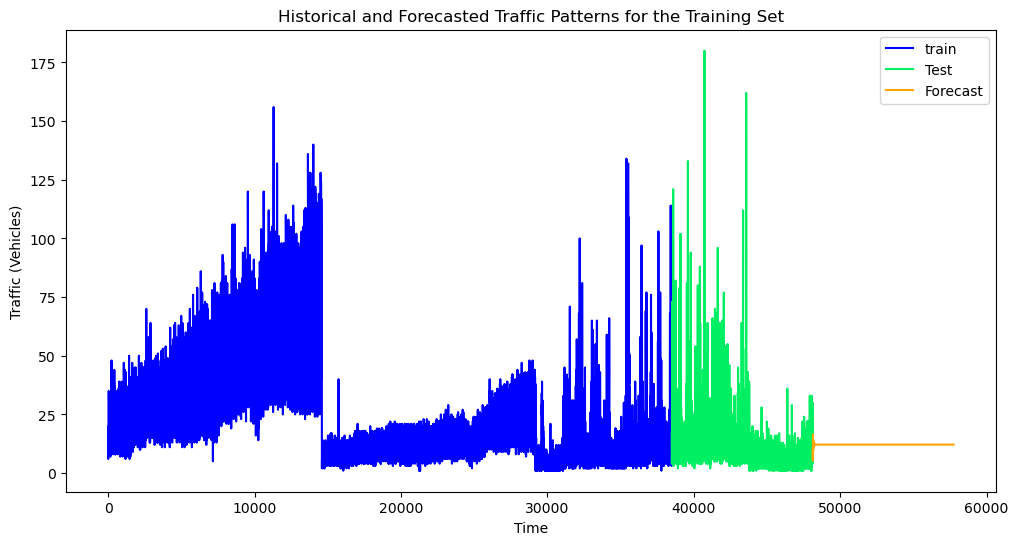

In [120]:
plt.figure(figsize=(12, 6))
plt.plot(train_df.index, train_df['Vehicles'].values, label='train', color='b')
#plt.plot(future_forecaste['predicted_mean'].index, future_forecaste['predicted_mean'].values, label='Forecasted Traffic', color='r')#,linewidth=10, alpha=0.8)
plt.plot(test_df.index, test_df["Vehicles"], label='Test', color='#01ef63')
plt.plot(train_forecast['predicted_mean'].index, train_forecast['predicted_mean'].values, label='Forecast', color='orange')
plt.xlabel('Time')
plt.ylabel('Traffic (Vehicles)')
plt.title('Historical and Forecasted Traffic Patterns for the Training Set')
plt.legend()
plt.show()

In [ ]:
# Transitioning to LSTM

In [166]:

from keras.models import Sequential
from keras.layers import LSTM, Dense

ModuleNotFoundError: No module named 'tensorflow.python'

In [130]:
df.dtypes

Junction              int64
Vehicles              int64
Hour                  int32
Date         datetime64[ns]
Year                  int32
weekday               int32
IsHoliday             int64
dtype: object

In [131]:
df['pd'] = df['Vehicles'].shift(24)
df['Ph'] = df['Vehicles'].shift(1)

In [132]:
df

,Junction,Vehicles,Hour,Date,Year,weekday,IsHoliday,pd,Ph
0,1,15,0,2015-11-01,2015,7,0,NaN,NaN
1,1,13,1,2015-11-01,2015,7,0,NaN,15.0
2,1,10,2,2015-11-01,2015,7,0,NaN,13.0
3,1,7,3,2015-11-01,2015,7,0,NaN,10.0
4,1,9,4,2015-11-01,2015,7,0,NaN,7.0
...,...,...,...,...,...,...,...,...,...
48115,4,11,19,2017-06-30,2017,5,0,9.0,17.0
48116,4,30,20,2017-06-30,2017,5,0,13.0,11.0
48117,4,16,21,2017-06-30,2017,5,0,12.0,30.0
48118,4,22,22,2017-06-30,2017,5,0,15.0,16.0


In [133]:
df['pd']=df['pd'].fillna(0)

In [136]:
df['Ph']=df['Ph'].fillna(0)

In [137]:
df

,Junction,Vehicles,Hour,Date,Year,weekday,IsHoliday,pd,Ph
0,1,15,0,2015-11-01,2015,7,0,0.0,0.0
1,1,13,1,2015-11-01,2015,7,0,0.0,15.0
2,1,10,2,2015-11-01,2015,7,0,0.0,13.0
3,1,7,3,2015-11-01,2015,7,0,0.0,10.0
4,1,9,4,2015-11-01,2015,7,0,0.0,7.0
...,...,...,...,...,...,...,...,...,...
48115,4,11,19,2017-06-30,2017,5,0,9.0,17.0
48116,4,30,20,2017-06-30,2017,5,0,13.0,11.0
48117,4,16,21,2017-06-30,2017,5,0,12.0,30.0
48118,4,22,22,2017-06-30,2017,5,0,15.0,16.0


In [144]:
df['pd'].value_counts()

pd
8.0      2325
9.0      2288
7.0      2218
6.0      2204
10.0     2144
         ... 
143.0       1
156.0       1
141.0       1
135.0       1
162.0       1
Name: count, Length: 142, dtype: int64

In [146]:
df['Ph'].value_counts()

Ph
8.0      2325
9.0      2290
7.0      2220
6.0      2206
10.0     2145
         ... 
156.0       1
141.0       1
135.0       1
143.0       1
162.0       1
Name: count, Length: 142, dtype: int64

In [147]:
df.dtypes

Junction              int64
Vehicles              int64
Hour                  int32
Date         datetime64[ns]
Year                  int32
weekday               int32
IsHoliday             int64
pd                  float64
Ph                  float64
dtype: object

In [148]:
df['Vehicles'] = df['Vehicles'].astype(float)

In [149]:
df.dtypes

Junction              int64
Vehicles            float64
Hour                  int32
Date         datetime64[ns]
Year                  int32
weekday               int32
IsHoliday             int64
pd                  float64
Ph                  float64
dtype: object

In [150]:
#
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [151]:
df

,Junction,Vehicles,Hour,Date,Year,weekday,IsHoliday,pd,Ph,Month,Day
0,1,15.0,0,2015-11-01,2015,7,0,0.0,0.0,11,1
1,1,13.0,1,2015-11-01,2015,7,0,0.0,15.0,11,1
2,1,10.0,2,2015-11-01,2015,7,0,0.0,13.0,11,1
3,1,7.0,3,2015-11-01,2015,7,0,0.0,10.0,11,1
4,1,9.0,4,2015-11-01,2015,7,0,0.0,7.0,11,1
...,...,...,...,...,...,...,...,...,...,...,...
48115,4,11.0,19,2017-06-30,2017,5,0,9.0,17.0,6,30
48116,4,30.0,20,2017-06-30,2017,5,0,13.0,11.0,6,30
48117,4,16.0,21,2017-06-30,2017,5,0,12.0,30.0,6,30
48118,4,22.0,22,2017-06-30,2017,5,0,15.0,16.0,6,30


In [153]:
df.isnull().sum()

Junction     0
Vehicles     0
Hour         0
Date         0
Year         0
weekday      0
IsHoliday    0
pd           0
Ph           0
Month        0
Day          0
dtype: int64

In [155]:
df.dtypes

Junction              int64
Vehicles            float64
Hour                  int32
Date         datetime64[ns]
Year                  int32
weekday               int32
IsHoliday             int64
pd                  float64
Ph                  float64
Month                 int32
Day                   int32
dtype: object

In [156]:
df.tail()

,Junction,Vehicles,Hour,Date,Year,weekday,IsHoliday,pd,Ph,Month,Day
48115,4,11.0,19,2017-06-30,2017,5,0,9.0,17.0,6,30
48116,4,30.0,20,2017-06-30,2017,5,0,13.0,11.0,6,30
48117,4,16.0,21,2017-06-30,2017,5,0,12.0,30.0,6,30
48118,4,22.0,22,2017-06-30,2017,5,0,15.0,16.0,6,30
48119,4,12.0,23,2017-06-30,2017,5,0,11.0,22.0,6,30


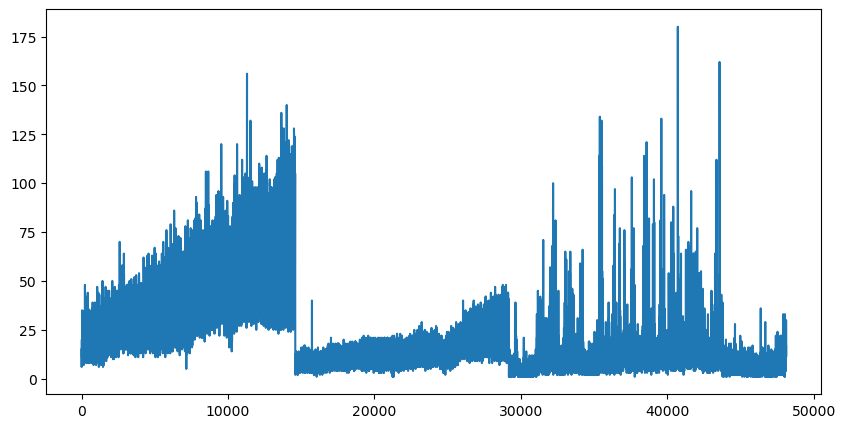

In [161]:
plt.figure(figsize=(10,5))
plt.plot(df['Vehicles'])
plt.show()

In [ ]:
# minmax scaler

In [163]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df['Vehicles']=scaler.fit_transform(df[['Vehicles']])


In [164]:
df

,Junction,Vehicles,Hour,Date,Year,weekday,IsHoliday,pd,Ph,Month,Day
0,1,0.078212,0,2015-11-01,2015,7,0,0.0,0.0,11,1
1,1,0.067039,1,2015-11-01,2015,7,0,0.0,15.0,11,1
2,1,0.050279,2,2015-11-01,2015,7,0,0.0,13.0,11,1
3,1,0.033520,3,2015-11-01,2015,7,0,0.0,10.0,11,1
4,1,0.044693,4,2015-11-01,2015,7,0,0.0,7.0,11,1
...,...,...,...,...,...,...,...,...,...,...,...
48115,4,0.055866,19,2017-06-30,2017,5,0,9.0,17.0,6,30
48116,4,0.162011,20,2017-06-30,2017,5,0,13.0,11.0,6,30
48117,4,0.083799,21,2017-06-30,2017,5,0,12.0,30.0,6,30
48118,4,0.117318,22,2017-06-30,2017,5,0,15.0,16.0,6,30
